# Figures
This notebook is for generating figures in the main text manuscript as well as the supplementary information.

In [1]:
import os

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import numpy as np
import pandas as pd
import rioxarray as rxr
import seaborn as sns
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib_map_utils.core.scale_bar import ScaleBar, scale_bar

from config import (
    GADM_FILE,
    PROCESSED_DIR,
    INTERIM_DIR,
    REPORTS_DIR,
    MODEL_NAMES,
    MODEL_PAIRS,
)
from modules.utils import countries, read_boundary

### Figure 1: Spatial agreement of model predictions

Text(0, 0.5, '')

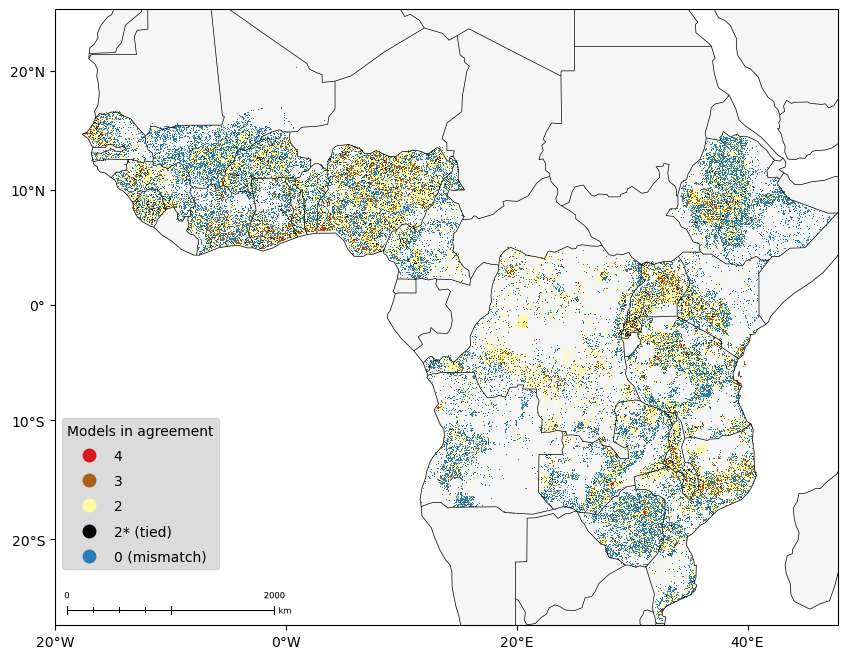

In [3]:
# read spatial agreement raster for combined countries
rasters = rxr.open_rasterio(
    os.path.join(PROCESSED_DIR, "spatial_agreement_map_old.tif")
).squeeze()
# template layer for plotting
template = gpd.read_file(GADM_FILE, layer="SA_template")
# using projected crs
mercator = ccrs.Mercator()
template = template.to_crs(mercator.proj4_init)
rasters = rasters.rio.reproject(mercator.proj4_init)
# create a colormap for the agreement values
qmap = ListedColormap(["#2c7bb6", "#000000", "#fcfca2", "#a6611a", "#d7191c"])
# ["#2c7bb6","#000000","#a6d96a","#fcfca2","#d7191c"]
# ["#2c7bb6","#25db0d","#fcfca2","#a6611a","#d7191c"]

fig, axs = plt.subplots(1, 1, figsize=(15, 8), subplot_kw={"projection": mercator})
# plot the data
rasters.plot.imshow(ax=axs, cmap=qmap, add_colorbar=False)
# add country boundaries and other features
axs.coastlines(linewidth=0.5)
axs.add_feature(cfeature.BORDERS, linewidth=0.5)
axs.add_feature(cfeature.LAND, color="lightgrey", alpha=0.2)
# axs.add_feature(cfeature.OCEAN, color=cfeature.COLORS['water'], alpha=0.2)
template.plot(
    ax=axs,
    column="Value",
    markersize=0.1,
    categorical=True,
    cmap=qmap,
    legend=True,
    legend_kwds={
        "loc": "lower left",
        "bbox_to_anchor": (0, 0.08),
        "labelspacing": 0.8,
        "frameon": True,
        "reverse": True,
        "title": "Models in agreement",
        "labels": ["0 (mismatch)", "2* (tied)", "2", "3", "4"],
        "facecolor": "lightgrey",
    },
)
# add scale bar
ScaleBar.set_size("small")
scale_bar(
    axs,
    location="lower left",
    style="ticks",
    bar={
        "projection": template.crs,
        "max": 2000,
        "tick_loc": "middle",
        "major_div": 2,
        "minor_div": 4,
        "minor_type": "first",
    },
)
# add tickmarks
axs.set_xticks([-20, 0, 20, 40], crs=ccrs.PlateCarree())
axs.set_yticks([-20, -10, 0, 10, 20], crs=ccrs.PlateCarree())
axs.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
axs.yaxis.set_major_formatter(LatitudeFormatter())

axs.set_title("")
axs.set_xlabel("")
axs.set_ylabel("")

# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "fig1.png"), dpi=300, bbox_inches="tight"
# )

### Figure 2: Majority vote ensemble poverty map

Text(0, 0.5, '')

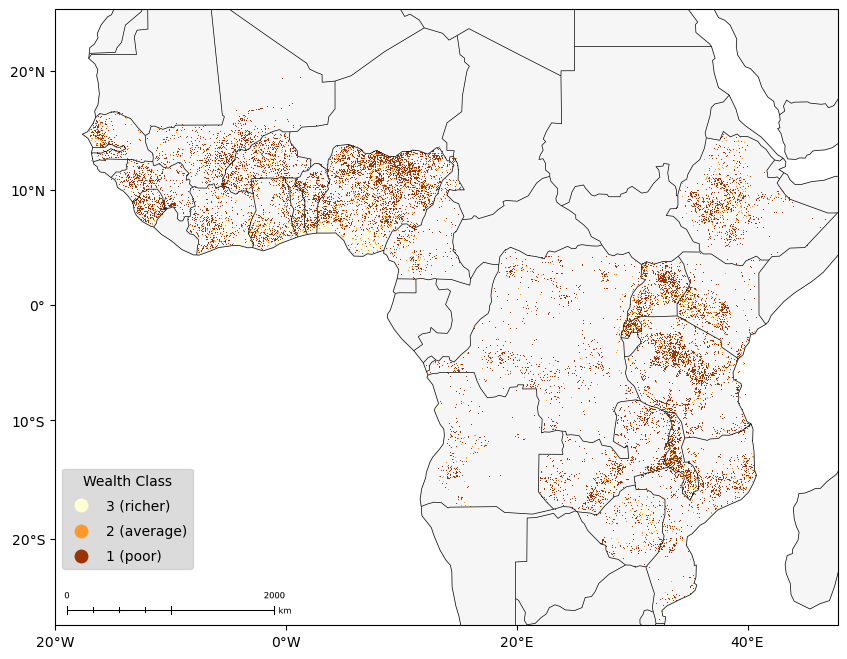

In [3]:
# read majority vote ensemble poverty map
rasters = rxr.open_rasterio(
    os.path.join(PROCESSED_DIR, "majority_ensemble_map.tif")
).squeeze()
# template layer for plotting
template = gpd.read_file(GADM_FILE, layer="tercile_ensemble_zwe")
# using projected crs
mercator = ccrs.Mercator()
template = template.to_crs(mercator.proj4_init)
template = template[template["Value"] != 0]
rasters = rasters.rio.reproject(mercator.proj4_init)
# create a colormap for the wealth classes
qmap = ListedColormap(["#993404", "#fe9929", "#ffffd4"])  # poor, average, richer
# ["#aa750adc","#e76e1e", '#fec44f']

fig, axs = plt.subplots(1, 1, figsize=(15, 8), subplot_kw={"projection": mercator})
# plot the data
rasters.plot.imshow(ax=axs, cmap=qmap, add_colorbar=False)
# add country boundaries and other features
axs.coastlines(linewidth=0.5)
axs.add_feature(cfeature.BORDERS, linewidth=0.5)
axs.add_feature(cfeature.LAND, color="lightgrey", alpha=0.2)
# axs.add_feature(cfeature.OCEAN, color=cfeature.COLORS['water'], alpha=0.2)
template.plot(
    ax=axs,
    column="Value",
    markersize=0.01,
    categorical=True,
    cmap=qmap,
    legend=True,
    legend_kwds={
        "loc": "lower left",
        "bbox_to_anchor": (0, 0.08),
        "labelspacing": 0.8,
        "frameon": True,
        "reverse": True,
        "title": "Wealth Class",
        "labels": ["1 (poor)", "2 (average)", "3 (richer)"],
        "facecolor": "lightgrey",
    },
)

# add scale bar
ScaleBar.set_size("small")
scale_bar(
    axs,
    location="lower left",
    style="ticks",
    bar={
        "projection": template.crs,
        "max": 2000,
        "tick_loc": "middle",
        "major_div": 2,
        "minor_div": 4,
        "minor_type": "first",
    },
)
# add tickmarks
axs.set_xticks([-20, 0, 20, 40], crs=ccrs.PlateCarree())
axs.set_yticks([-20, -10, 0, 10, 20], crs=ccrs.PlateCarree())
axs.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
axs.yaxis.set_major_formatter(LatitudeFormatter())

axs.set_title("")
axs.set_xlabel("")
axs.set_ylabel("")
# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "fig2.png"), dpi=300, bbox_inches="tight"
# )

### Figure 3: Discrepancies in pairwise agreement

In [8]:
# countries of interest
selected_countries = ["Democratic Republic of the Congo", "Uganda", "Mali", "Guinea"]
# pairwise agreement scores
proportions = pd.read_csv(os.path.join(PROCESSED_DIR, "Pairwise_wealth_classes.csv"))
# tickmarks for plotting
xticks_list = [[15, 20, 25, 30], [30, 32, 34], [-12, -8, -4, 0, 4], [-14, -12, -10, -8]]
yticks_list = [[-10, -5, 0, 5], [-2, 0, 2, 4], [12, 16, 20, 24], [8, 10, 12]]
# using projected crs
mercator = ccrs.Mercator()
# read pairwise comparison maps for selected countries
data_dict = dict()
for country, xticks, yticks in zip(selected_countries, xticks_list, yticks_list):
    data_dict[country] = dict()
    model_pair = "Lee_McCallum" if country == "Guinea" else "McCallum_Yeh"
    # filter agreement metrics for the country
    metrics = proportions[proportions["Country"] == country]

    # read the raster data and boundary for each country
    data_dict[country]["data"] = (
        rxr.open_rasterio(
            os.path.join(
                INTERIM_DIR,
                "raster_stacks",
                "pairwise_agreement",
                f"{model_pair}_{country}_models.tif",
            ),
            masked=True,
        )
        .squeeze()
        .rio.reproject(mercator.proj4_init)
    )
    data_dict[country]["boundary"] = read_boundary(country).to_crs(mercator.proj4_init)
    # add tickmarks for each country
    data_dict[country]["xticks"] = xticks
    data_dict[country]["yticks"] = yticks
    # get agreement score and number of pixels
    data_dict[country]["model_pair"] = model_pair
    data_dict[country]["agree"] = metrics.loc[
        metrics["model_pair"] == model_pair, "agree"
    ].values[0]
    data_dict[country]["N"] = metrics.loc[
        metrics["model_pair"] == model_pair, "N"
    ].values[0]

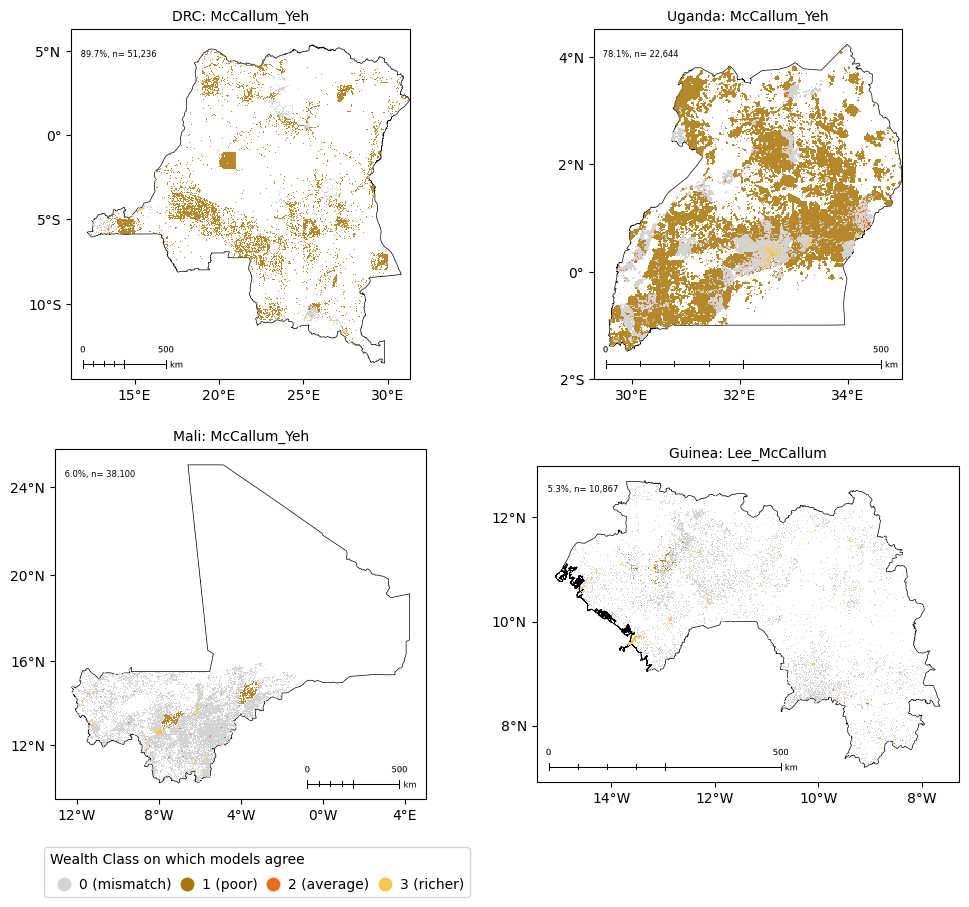

In [9]:
# create a colormap for the wealth terciles
qmap = ListedColormap(
    ["lightgrey", "#aa750adc", "#e76e1e", "#fec44f"]
)  # mismatch, poor, average, richer
# add scale bar
ScaleBar.set_size("small")
fig, axs = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={"projection": mercator})
# plot maps and boundaries
for ax, country in zip(axs.flatten(), selected_countries):
    data_dict[country]["boundary"].plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=0.5
    )
    data_dict[country]["data"].plot(ax=ax, cmap=qmap, add_colorbar=False)
    # add annotation
    label = "DRC" if country.endswith("Congo") else country
    ax.text(
        0.02,
        0.92,
        f"{data_dict[country]['agree']: .1f}%, n={data_dict[country]['N']: ,}",
        fontsize=6,
        ha="left",
        transform=ax.transAxes,
    )
    ax.set_title(f"{label}: {data_dict[country]['model_pair']}", fontsize=10)

    # add scale bar
    scale_bar(
        ax,
        location="lower left" if country != "Mali" else "lower right",
        style="ticks",
        bar={
            "projection": mercator.proj4_init,
            "max": 500,
            "tick_loc": "middle",
            "major_div": 2,
            "minor_div": 4,
            "minor_type": "first",
        },
    )

    # add tickmarks
    ax.set_xticks(data_dict[country]["xticks"], crs=ccrs.PlateCarree())
    ax.set_yticks(data_dict[country]["yticks"], crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.set_xlabel("")
    ax.set_ylabel("")

# read template layer for plotting
template = gpd.read_file(GADM_FILE, layer="tercile_ensemble_cod")
template = template.to_crs(mercator.proj4_init)
# plot the template layer with wealth terciles
template.plot(
    ax=axs[0, 0],
    column="Value",
    markersize=0.1,
    categorical=True,
    cmap=qmap,
    legend=True,
    categories=[0, 1, 2, 3],
    legend_kwds={
        "ncols": 4,
        "loc": "lower left",
        "labelspacing": 0.8,
        "frameon": True,
        "reverse": False,
        "alignment": "left",
        "title": "Wealth Class on which models agree",
        "bbox_to_anchor": (-0.1, -1.5),
        "columnspacing": 0.1,
        "handletextpad": 0.1,
        "labels": ["0 (mismatch)", "1 (poor)", "2 (average)", "3 (richer)"],
    },
)

plt.savefig(
    os.path.join(REPORTS_DIR, "figures", "fig3.png"), dpi=300, bbox_inches="tight"
)

### Figure 4: Model performance boxplots

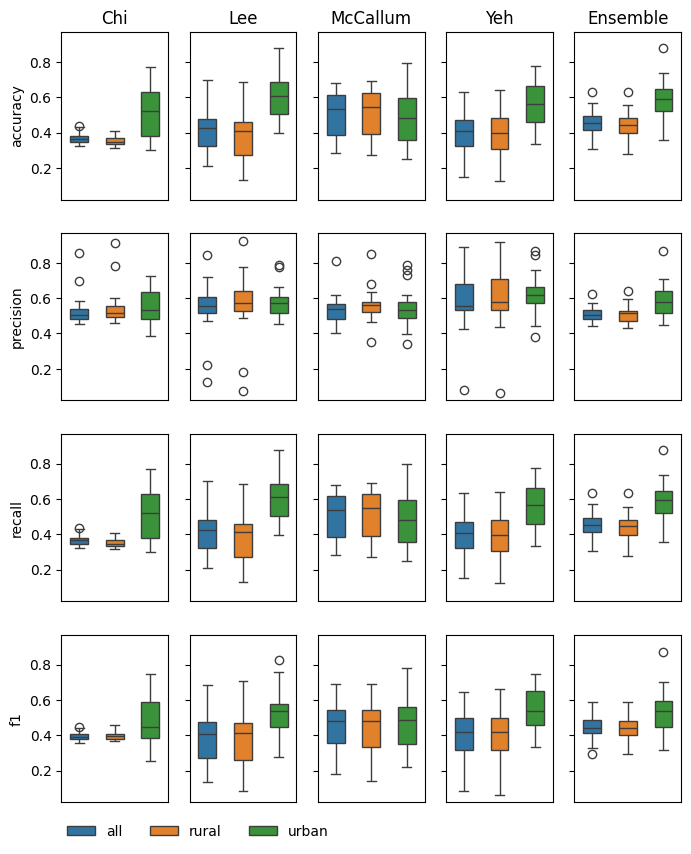

In [3]:
# read performance metrics for individual countries
df=pd.read_csv(os.path.join(outputs, 'disaggregated_analysis', 'terciles', 'dhs_country_metrics_combined_full.csv'))
df=df.sort_values(by=['stratum'])

fig, axs=plt.subplots(4, len(model_list)+1, sharey=True, sharex=True, figsize=(8, 10))
for idy, metric in enumerate(['accuracy', 'precision', 'recall', 'f1']):
    for idx, model in enumerate(model_list+['Ensemble']):
        sns.boxplot(df[df['metric']==metric], x='stratum', y=model, hue='stratum', width=0.5, legend=True, ax=axs[idy, idx])
        axs[0, idx].set_title(f'{model}')
    axs[idy, 0].set_ylabel(metric)

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.legend().set_visible(False)
axs[3, 0].legend(loc=(0, -0.25), ncol=3, frameon=False).set_visible(True)

# plt.savefig(os.path.join(outputs, 'figs', 'terciles', 'fig4.png'), dpi=300, bbox_inches='tight')

### SI Figure 1: Unanimous vote ensemble poverty map

Text(0, 0.5, '')

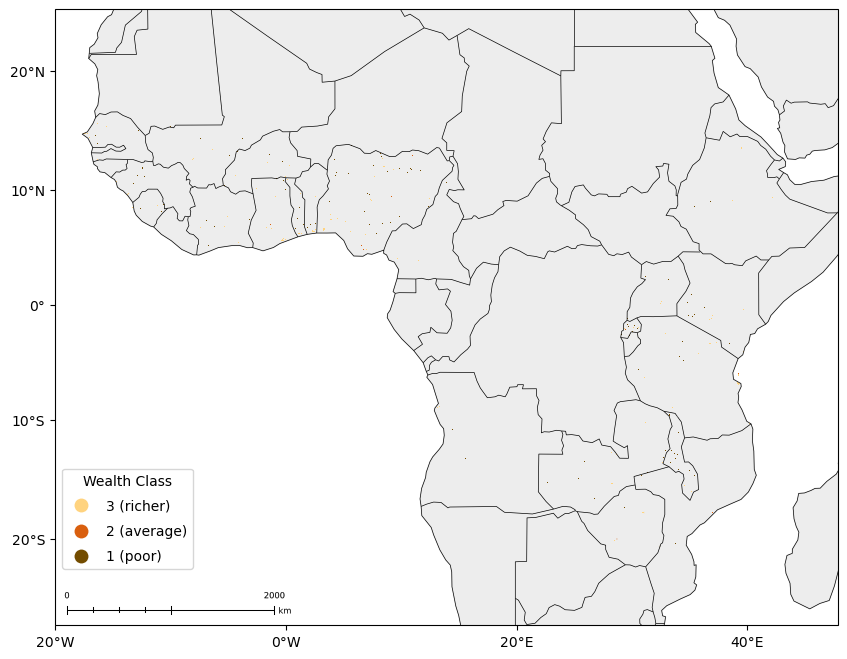

In [4]:
# read unanimous vote ensemble poverty map
rasters = rxr.open_rasterio(
    os.path.join(PROCESSED_DIR, "unanimous_ensemble_map.tif")
).squeeze()
# template layer for plotting
template = gpd.read_file(GADM_FILE, layer="tercile_ensemble_zwe")
# using projected crs
mercator = ccrs.Mercator()
template = template.to_crs(mercator.proj4_init)
template = template[template["Value"] != 0]
rasters = rasters.rio.reproject(mercator.proj4_init)
# create a colormap for the wealth terciles
qmap = ListedColormap(["#734C00", "#D95F0E", "#FFD37F"])  # poor, average, richer

fig, axs = plt.subplots(1, 1, figsize=(15, 8), subplot_kw={"projection": mercator})
# plot the data
rasters.plot.imshow(ax=axs, cmap=qmap, add_colorbar=False)
# add country boundaries and other features
axs.coastlines(linewidth=0.5)
axs.add_feature(cfeature.BORDERS, linewidth=0.5)
axs.add_feature(cfeature.LAND, color="lightgrey", alpha=0.4)
template.plot(
    ax=axs,
    column="Value",
    markersize=0.01,
    categorical=True,
    cmap=qmap,
    legend=True,
    legend_kwds={
        "loc": "lower left",
        "bbox_to_anchor": (0, 0.08),
        "labelspacing": 0.8,
        "frameon": True,
        "reverse": True,
        "title": "Wealth Class",
        "labels": ["1 (poor)", "2 (average)", "3 (richer)"],
    },
)

# add scale bar
ScaleBar.set_size("small")
scale_bar(
    axs,
    location="lower left",
    style="ticks",
    bar={
        "projection": template.crs,
        "max": 2000,
        "tick_loc": "middle",
        "major_div": 2,
        "minor_div": 4,
        "minor_type": "first",
    },
)
# add tickmarks
axs.set_xticks([-20, 0, 20, 40], crs=ccrs.PlateCarree())
axs.set_yticks([-20, -10, 0, 10, 20], crs=ccrs.PlateCarree())
axs.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
axs.yaxis.set_major_formatter(LatitudeFormatter())

axs.set_title("")
axs.set_xlabel("")
axs.set_ylabel("")
# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "SI_fig1.png"), dpi=300, bbox_inches="tight"
# )

### SI Figure 2: Pairwise agreement heatmap

Text(70.72222222222221, 0.5, '')

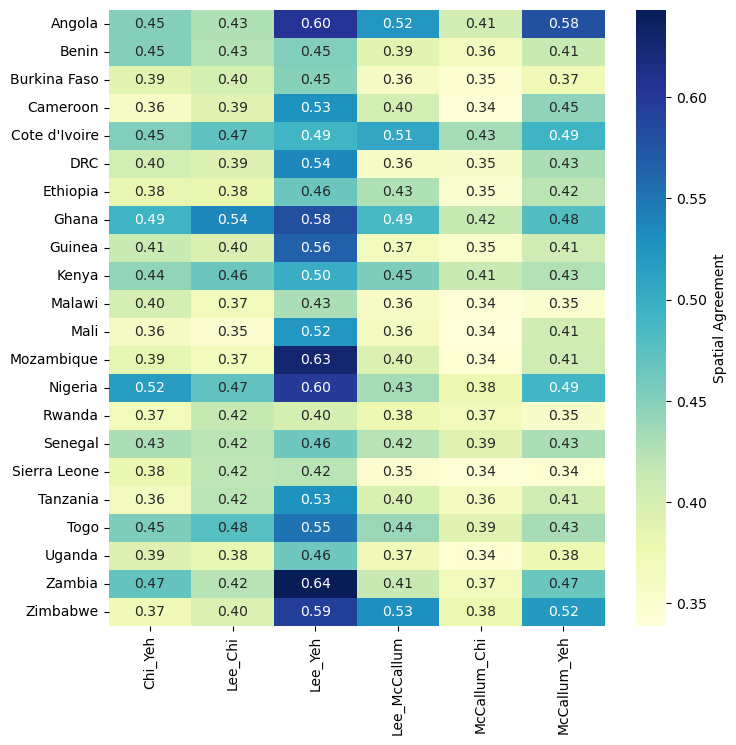

In [5]:
# read pairwise agreement proportions
proportions = pd.read_csv(
    os.path.join(PROCESSED_DIR, "Pairwise_agreement_pix_stats.csv")
)
proportions["Country"] = proportions["Country"].replace(
    {"Democratic Republic of the Congo": "DRC"}
)
# proportions=(proportions[proportions['Country']!='Togo'])
proportions = (proportions.set_index("Country").map(lambda x: x / 100))[MODEL_PAIRS]
# plot the data
fig, axs = plt.subplots(1, 1, figsize=(8, 8))
sns.heatmap(
    proportions,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Spatial Agreement"},
)
axs.set_ylabel("")
# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "SI_fig2.png"), dpi=300, bbox_inches="tight"
# )

### SI Figure 3: Pairwise agreement maps

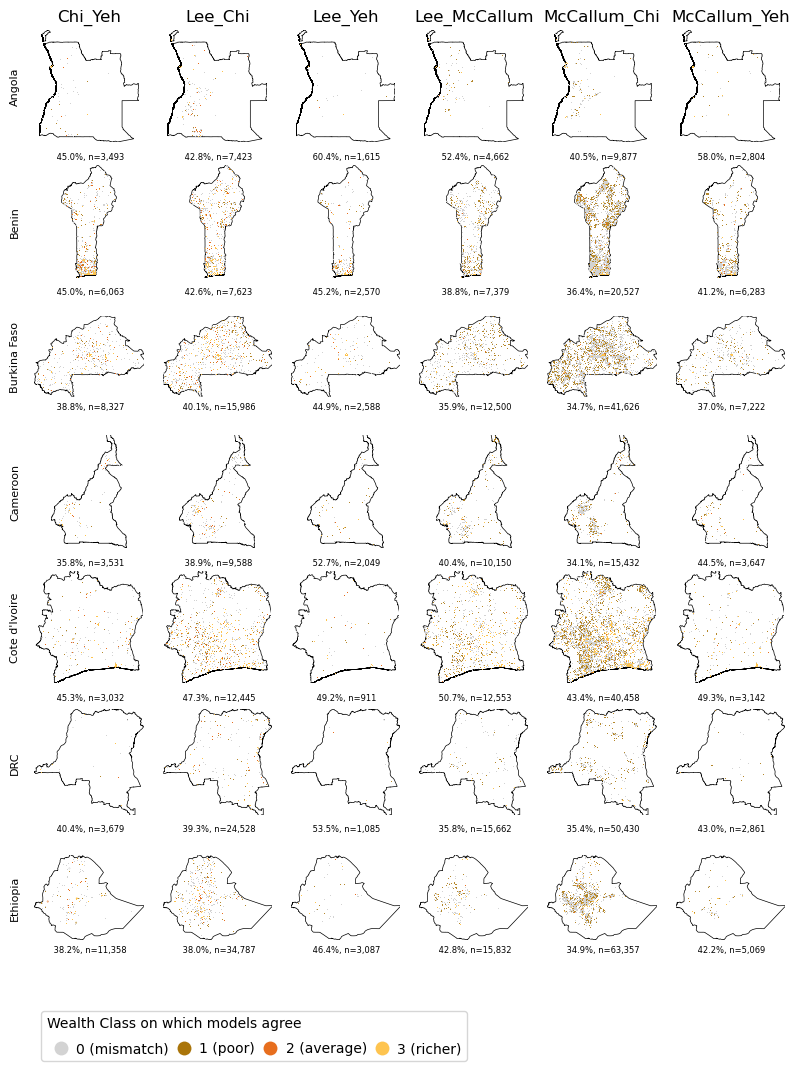

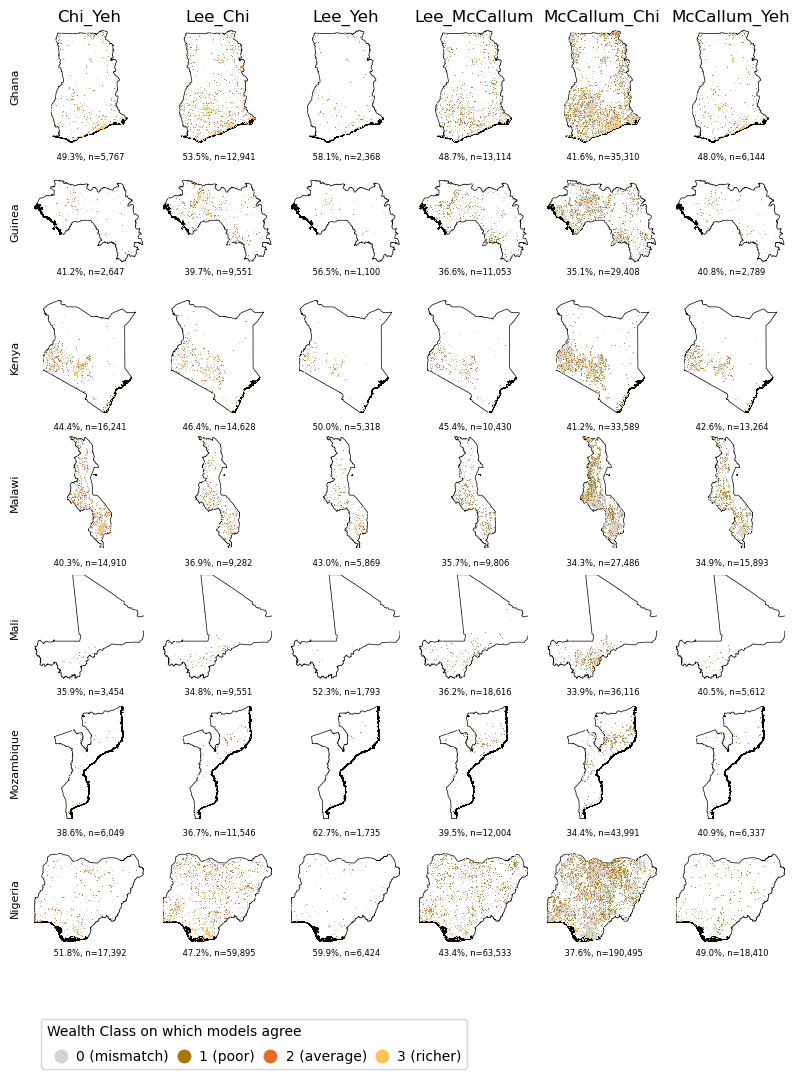

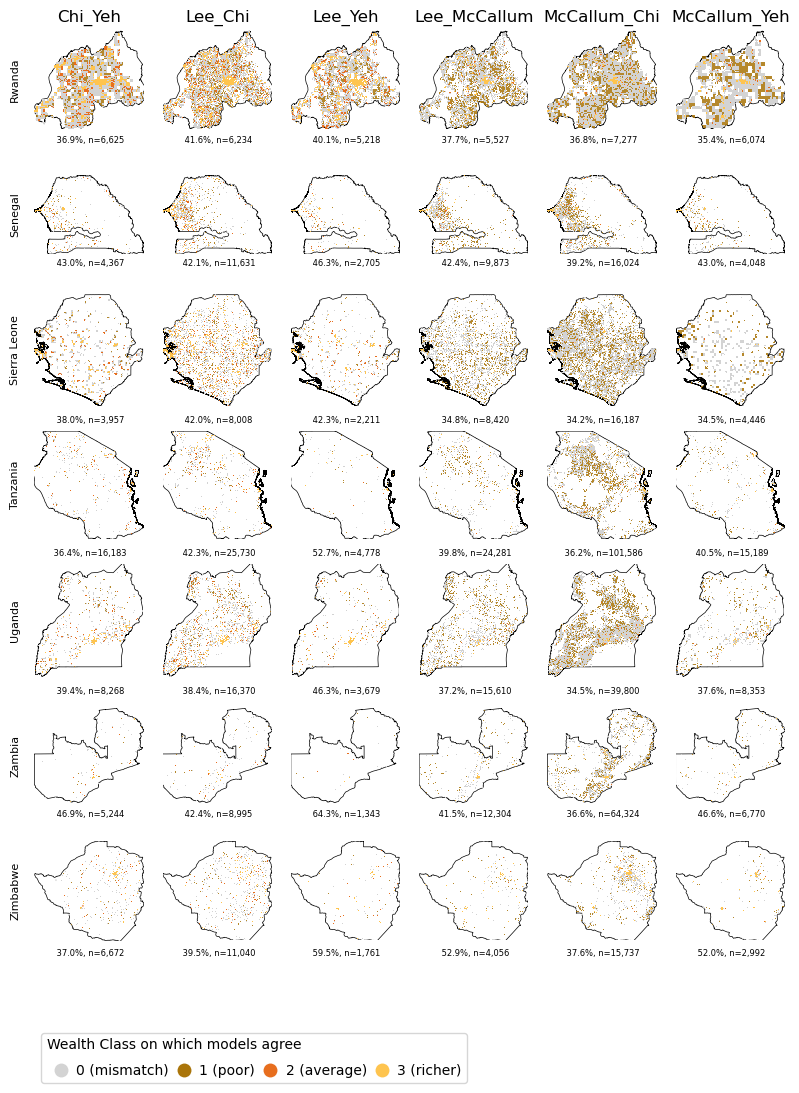

In [6]:
proportions = pd.read_csv(os.path.join(PROCESSED_DIR, "Pairwise_wealth_classes.csv"))
# create a colormap for the wealth terciles
qmap = ListedColormap(
    ["lightgrey", "#aa750adc", "#e76e1e", "#fec44f"]
)  # mismatch, poor, average, richer

for n, (tplt, grp) in enumerate(
    zip(["eth", "nga", "zwe"], [slice(0, 7), slice(7, 14), slice(14, 21)])
):
    # prepare the axes for plotting
    fig = plt.figure(constrained_layout=False, figsize=(10, 12))
    spec = fig.add_gridspec(ncols=7, nrows=7, width_ratios=[0.05, 1, 1, 1, 1, 1, 1])
    axs = np.empty((7, 7), dtype=object)
    for i in range(7):
        for j in range(7):
            axs[i, j] = fig.add_subplot(spec[i, j])

    # template layer for plotting
    template = gpd.read_file(GADM_FILE, layer=f"tercile_ensemble_{tplt}")

    for idy, cntry in enumerate(
        [i for i in countries.keys() if not i.endswith("Togo")][grp]
    ):
        # read the country boundary
        boundary = read_boundary(cntry)
        # filter agreement metrics for the country
        metrics = proportions[proportions["Country"] == cntry]

        for idx, pair in enumerate(MODEL_PAIRS, start=1):
            # read agreement map for current model pair
            da = rxr.open_rasterio(
                os.path.join(
                    INTERIM_DIR,
                    "raster_stacks",
                    "pairwise_agreement",
                    f"{pair}_{cntry}_models.tif",
                ),
                masked=True,
            ).squeeze()
            # plot map and boundary
            boundary.plot(
                ax=axs[idy, idx], facecolor="none", edgecolor="black", linewidth=0.5
            )
            da.plot(ax=axs[idy, idx], cmap=qmap, add_colorbar=False)
            # get agreement score and plot
            agree = metrics.loc[metrics["model_pair"] == pair, "agree"].values[0]
            N = metrics.loc[metrics["model_pair"] == pair, "N"].values[0]
            axs[idy, idx].text(
                0.5,
                -0.15,
                f"{agree: .1f}%, n={N:,}",
                fontsize=6,
                ha="center",
                transform=axs[idy, idx].transAxes,
            )
            axs[idy, idx].set_title("")

        # label countries
        cntry = cntry if not cntry.endswith("Congo") else "DRC"
        axs[idy, 0].annotate(
            f"{cntry}",
            (0, 0.5),
            fontsize=8,
            va="center",
            transform=axs[idy, idx].transAxes,
            rotation=90,
        )
    # plot the template layer with wealth terciles
    template.plot(
        ax=axs[6, 1],
        column="Value",
        markersize=0.1,
        categorical=True,
        cmap=qmap,
        legend=True,
        categories=[0, 1, 2, 3],
        legend_kwds={
            "ncols": 4,
            "loc": "lower left",
            "labelspacing": 0.8,
            "frameon": True,
            "reverse": False,
            "alignment": "left",
            "title": "Wealth Class on which models agree",
            "bbox_to_anchor": (0, -1.5),
            "columnspacing": 0.1,
            "handletextpad": 0.1,
            "labels": ["0 (mismatch)", "1 (poor)", "2 (average)", "3 (richer)"],
        },
    )
    for ax in axs.flatten():
        ax.set_axis_off()
    for ax, pair in zip(axs[0, 1:], MODEL_PAIRS):
        ax.set_title(pair)

    # plt.savefig(
    #     os.path.join(REPORTS_DIR, "figures", f"SI_fig3_{n}.png"),
    #     dpi=300,
    #     bbox_inches="tight",
    # )


### SI Figure 4: Pairwise wealth categories

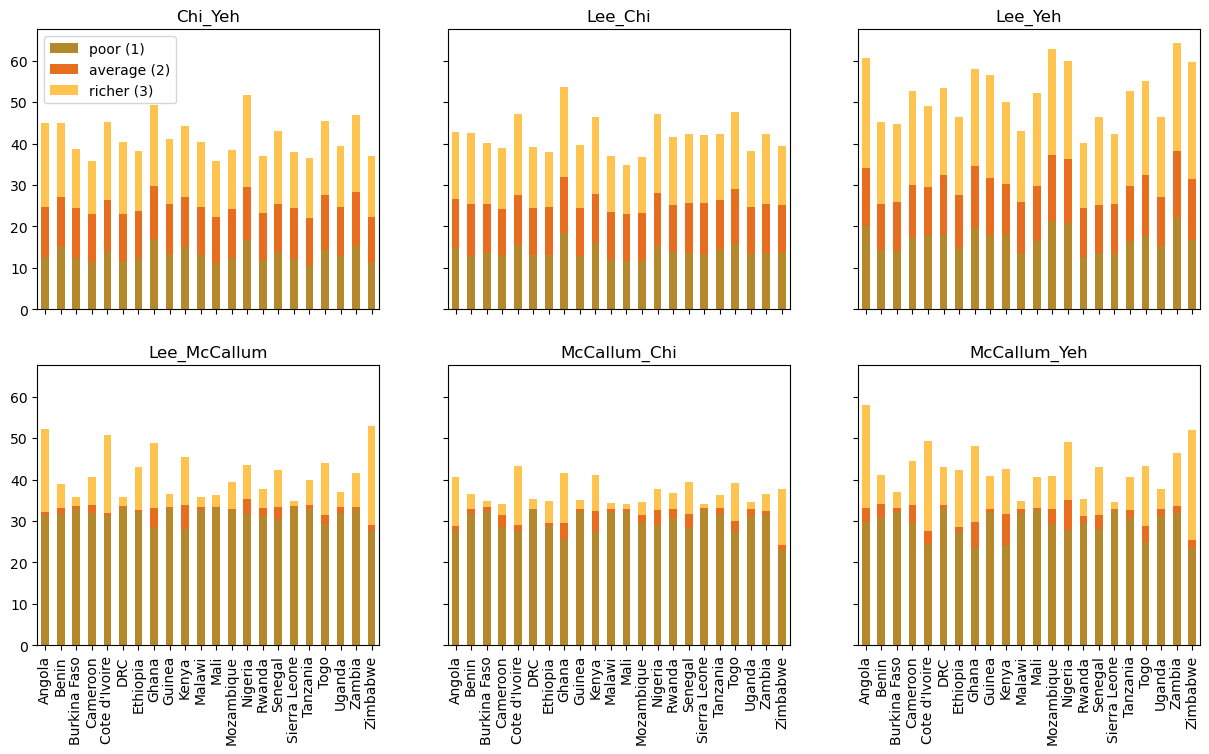

In [7]:
# read data
proportions = pd.read_csv(os.path.join(PROCESSED_DIR, "Pairwise_wealth_classes.csv"))
proportions["Country"] = proportions["Country"].replace(
    {"Democratic Republic of the Congo": "DRC"}
)
proportions = proportions[
    ["Country", "model_pair", "poor (1)", "average (2)", "richer (3)"]
].set_index("Country")
model_pairs = np.array(MODEL_PAIRS).reshape(2, 3)

fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharey=True, sharex=True)
# plot the data
for i in range(2):
    for j in range(3):
        proportions[proportions["model_pair"] == model_pairs[i, j]].plot(
            kind="bar",
            stacked=True,
            ax=axs[i, j],
            color=["#aa750adc", "#e76e1e", "#fec44f"],
            legend=True,
        )
        axs[i, j].set_title(f"{model_pairs[i, j]}")
        axs[i, j].set_xlabel("")
for ax in axs.flatten()[1:]:
    ax.legend().set_visible(False)
# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "SI_fig4.png"), dpi=300, bbox_inches="tight"
# )

### SI Figure 5: Ensembles boxplots

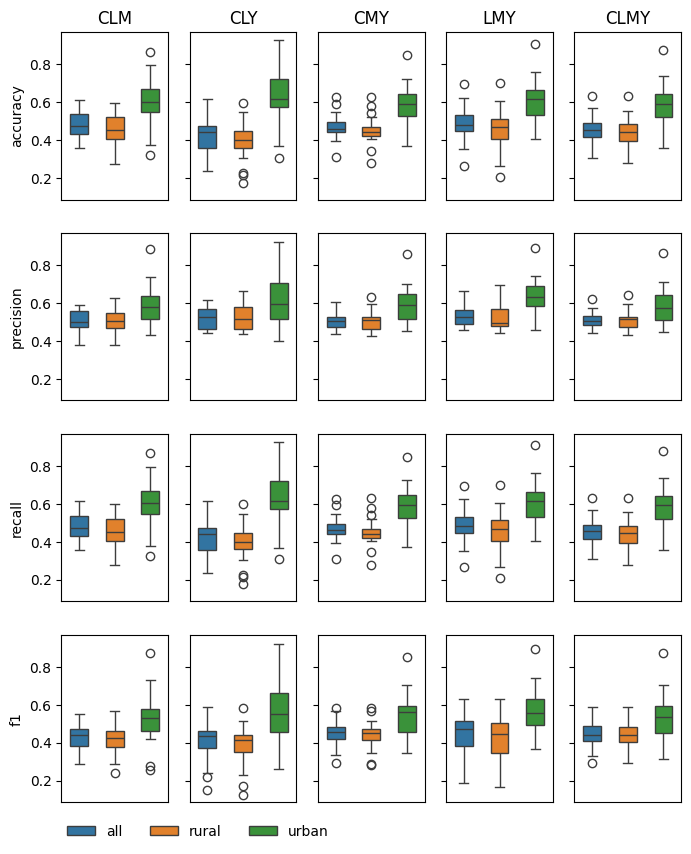

In [ ]:
# read metrics for the different ensemble models
df=pd.read_csv(os.path.join(outputs, 'Ensemble_models_new', 'dhs_ensemble_comparisons.csv'))
df=df.sort_values(by=['stratum'])
model_list=['CLM', 'CLY', 'CMY', 'LMY']

fig, axs=plt.subplots(4, len(model_list)+1, sharey=True, sharex=True, figsize=(8, 10))
for idy, metric in enumerate(['accuracy', 'precision', 'recall', 'f1']):
    for idx, model in enumerate(model_list+['CLMY']):
        sns.boxplot(df[df['metric']==metric], x='stratum', y=model, hue='stratum', width=0.5, legend=True, ax=axs[idy, idx])
        axs[0, idx].set_title(f'{model}')
    axs[idy, 0].set_ylabel(metric)

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.legend().set_visible(False)
axs[3, 0].legend(loc=(0, -0.25), ncol=3, frameon=False).set_visible(True)
# plt.savefig(os.path.join(outputs, 'figs', 'terciles', 'SI_fig5.png'), dpi=300, bbox_inches='tight')

### SI Figure 6: Base models and best ensemble boxplots

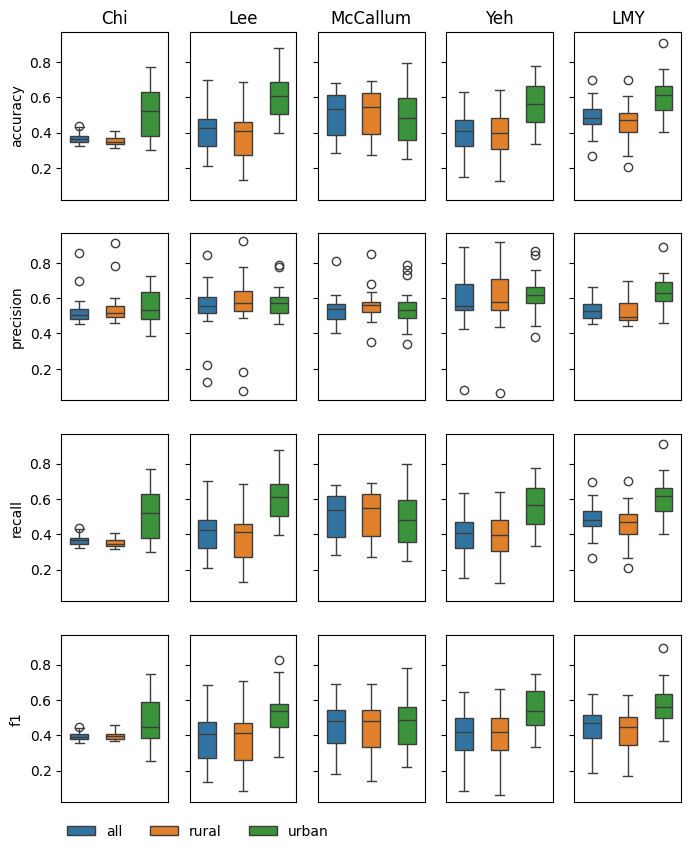

In [ ]:
model_list=['Chi', 'Lee', 'McCallum', 'Yeh', 'LMY']
df=pd.read_csv(os.path.join(outputs, 'Ensemble_models_new', 'Best_dhs_ensemble_country_metrics_combined.csv'))
df=df.sort_values(by=['stratum'])

fig, axs=plt.subplots(4, len(model_list), sharey=True, sharex=True, figsize=(8, 10))
for idy, metric in enumerate(['accuracy', 'precision', 'recall', 'f1']):
    for idx, model in enumerate(model_list):
        sns.boxplot(df[df['metric']==metric], x='stratum', y=model, hue='stratum', width=0.5, legend=True, ax=axs[idy, idx])
        axs[0, idx].set_title(f'{model}')
    axs[idy, 0].set_ylabel(metric)

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.legend().set_visible(False)
axs[3, 0].legend(loc=(0, -0.25), ncol=3, frameon=False).set_visible(True)
# plt.savefig(os.path.join(outputs, 'figs', 'terciles', 'SI_fig6.png'), dpi=300, bbox_inches='tight')